## Методические указания по выполнению лабораторной работы №4

**Тема: Сегментация объектов с использованием Mask R-CNN**

**Цель работы:** Познакомиться с архитектурой Mask R-CNN и научиться выполнять сегментацию объектов на изображениях.

**Задачи:**

- Изучить теоретические основы instance segmentation.
- Ознакомиться с архитектурой Mask R-CNN.
- Провести инференс предобученной модели на выбранных изображениях.
- Визуализировать результаты: bounding boxes, маски объектов.
- Рассчитать метрики оценки качества масок.
- Проанализировать ошибки сегментации.
- Провести исследование зависимости качества от параметров confidence score и mask threshold.

### 1. Теоретическая часть

В данной лабораторной работе мы познакомимся с задачей детекции на примере архитектуры [Mask R-CNN](https://arxiv.org/pdf/1703.06870), обученной на наборе данных [COCO](https://cocodataset.org/#home), а также с новой задачей компьютерного зрения - сегментацией.

**Перед тем, как приступать к выполнению практической части, ознакомьтесь с первоисточниками используемых компонентов, а также документацией по [ссылке](https://pytorch.org/vision/main/models/mask_rcnn.html), включающей подробности работы с моделью и новым форматом данных, сэмплы кода.**

#### 1.1 Instance Segmentation и архитектура Mask R-CNN

Instance segmentation — это задача, в которой необходимо не только обнаружить объект и его класс, но и сегментировать его границы на уровне пикселей. Это усложнённая версия задачи детекции, так как bounding box не всегда точно соответствует форме объекта.

В отличие от semantic segmentation, где модель выдает одну маску на класс, в instance segmentation выделяется каждый объект независимо, даже если они относятся к одному классу.

Mask R-CNN — это расширение Faster R-CNN, дополненное ещё одним выходом: бинарной маской для каждого обнаруженного объекта.

Архитектура Mask R-CNN включает:

1. Backbone (например, ResNet-50) — извлекает карты признаков из изображения.
2. Region Proposal Network (RPN) — предлагает кандидаты на объекты.
3. ROI Align / ROI Pooling — извлекает фиксированные области из фичей.
4. Bounding Box Head — классифицирует объект и уточняет координаты.
5. Mask Head — предсказывает маску для каждого класса, соответствующую bounding box.


#### 1.2 Формат данных для задачи детекции

При запуске инференса модель возвращает словарь с результатами: координаты bounding boxes, классы объектов, confidence score и маски объектов (представлены как float значения от 0 до 1).

В рамках выполнения работы в зависимости от варианта вам предстоит познакомиться с другими форматами файлов и их содержимым.

### Варианты

 Номер по списку - 26 -> вариант задания -**2**

Выполните задание в соответствии со своим вариантом по списку с использованием предобученной модели.

Вариант 1  - Pascal VOC 2007. Сравнить предсказания модели с реальной разметкой и провести количественную оценку:

- Выполнить инференс модели на 20 изображениях;
- Визуализировать bounding boxes и маски;
- Проанализировать качество предсказаний;
- Описать, какие классы модель распознала, какие пропустила.

**Вариант 2 — COCO 2017. Сравнить предсказания модели с реальной разметкой и провести количественную оценку:**

- Выполнить инференс на 20 изображениях;
- Визуализировать предсказания;
- Сравнить полученные маски с ground truth;
- Рассчитать IoU, Pixel Accuracy или Precision/Recall;

Вариант 3 — Cityscapes. Проверить, как модель работает на новых изображениях, визуализировать предсказания и сравнить с известными аннотациями:

- Выполнить инференс на 20 изображениях;
- Визуализировать предсказания;
- Сравнить полученные маски с ground truth;
- Рассчитать IoU, Pixel Accuracy или Precision/Recall;


### 2. Практическая часть

#### 2.1 Подготовка окружения

Установите зависимости и библиотеки:

In [1]:
# импорт пакетов
import torch
import torchvision.models.detection as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
import torchvision

#### 2.2 Подготовка модели

Загрузите предобученную модель, определите устройство, переведите модель в режим инференса:

In [2]:
# импорт модели
model = models.maskrcnn_resnet50_fpn(weights="DEFAULT")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()
device

'cuda'

#### 2.3 Загрузка и предобработка изображений


Затем импортируйте датасет из соответствующих пакетов PyTorch и определите метод трансформации данных для подачи в модель:

In [3]:
val_ann_file = "content/annotations_trainval2017/annotations/instances_val2017.json"
val_img_dir = "content/val2017/val2017"
val_dataset = datasets.CocoDetection(root=val_img_dir, annFile=val_ann_file, transform=transforms.ToTensor())
print(val_dataset[0][1])

loading annotations into memory...
Done (t=2.17s)
creating index...
index created!
[{'segmentation': [[240.86, 211.31, 240.16, 197.19, 236.98, 192.26, 237.34, 187.67, 245.8, 188.02, 243.33, 176.02, 250.39, 186.96, 251.8, 166.85, 255.33, 142.51, 253.21, 190.49, 261.68, 183.08, 258.86, 191.2, 260.98, 206.37, 254.63, 199.66, 252.51, 201.78, 251.8, 212.01]], 'area': 531.8071000000001, 'iscrowd': 0, 'image_id': 139, 'bbox': [236.98, 142.51, 24.7, 69.5], 'category_id': 64, 'id': 26547}, {'segmentation': [[9.66, 167.76, 156.35, 173.04, 153.71, 256.48, 82.56, 262.63, 7.03, 260.87]], 'area': 13244.657700000002, 'iscrowd': 0, 'image_id': 139, 'bbox': [7.03, 167.76, 149.32, 94.87], 'category_id': 72, 'id': 34646}, {'segmentation': [[563.33, 209.19, 637.69, 209.19, 638.56, 287.92, 557.21, 280.04]], 'area': 5833.117949999999, 'iscrowd': 0, 'image_id': 139, 'bbox': [557.21, 209.19, 81.35, 78.73], 'category_id': 72, 'id': 35802}, {'segmentation': [[368.16, 252.94, 383.77, 255.69, 384.69, 235.49, 389.

In [4]:
classes = val_dataset.coco.loadCats(val_dataset.coco.getCatIds())
categories = {c['id']: c['name'] for c in classes}
print(categories)

{1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane', 6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light', 11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket', 44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed', 67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop', 74: 'mouse', 75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'micro

#### 2.4 Предсказания и извлечение масок

Если вы работаете с Pascal VOC, вам потребуется прочитать файлы, содержащие разметку. Если вы работаете с COCO или Cityscapes, аннотации читаются через готовые методы COCO API:

In [18]:
a = np.array([1,1, 1])
b = np.array([1, 1, 0])
((b == 1) & (a == 1)).sum()

np.int64(2)

In [ ]:
# методы извлечения меток и визуализации
def get_iou(*, gt_mask, mask):
  intersection = np.logical_and(gt_mask, mask)
  union = np.logical_or(gt_mask, mask)
  if union.sum() == 0:
      return 0
  iou = intersection.sum() / union.sum()
  return iou


def calculate_metrics(*, gt_mask, mask):
  gt_mask = gt_mask * 1
  mask = mask * 1
  fp = ((gt_mask == 0) & (mask == 1)).sum()
  fn = ((gt_mask == 1) & (mask == 0)).sum()
  tp = ((gt_mask == 1) & (mask == 1)).sum()
  return fn, fp, tp


def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        plt.show()
        

In [6]:
a = np.array([1, 1, 0, 1, 0])
b = np.array([1, 0, 1, 0, 0])
fn, fp = calculate_metrics(gt_mask=b, mask=a)
print(fn, fp)

1 2


#### 2.5 Оценка модели и визуализация результатов

Визуализируйте bounding box, название класса, маску поверх изображения. Для каждой маски и её соответствующего ground truth (если имеется), вычислите: IoU, количество FP пикселей, количество FN пикселей:

Mask label: chair, IoU = 0.5760642009769714, FP = 1018, FN = 197
Mask label: chair, IoU = 0.6809792843691149, FP = 404, FN = 443
Mask label: tv, IoU = 0.9543734698419765, FP = 232, FN = 383
Mask label: person, IoU = 0.8142950391644909, FP = 142, FN = 427
Mask label: potted plant, IoU = 0.5724907063197026, FP = 276, FN = 69
Mask label: clock, IoU = 0.8983739837398373, FP = 19, FN = 6
Mask label: vase, IoU = 0.6432160804020101, FP = 12, FN = 59
Mask label: dining table, IoU = 0.026800971310369636, FP = 8948, FN = 1873
Mask label: refrigerator, IoU = 0.3198324022346369, FP = 3668, FN = 228
Mask label: chair, IoU = 0.6752136752136753, FP = 229, FN = 265
Mask label: refrigerator, IoU = 0.0015841584158415843, FP = 2301, FN = 220
Mask label: vase, IoU = 0.3080168776371308, FP = 59, FN = 105
Mask label: potted plant, IoU = 0.008526187576126675, FP = 701, FN = 113


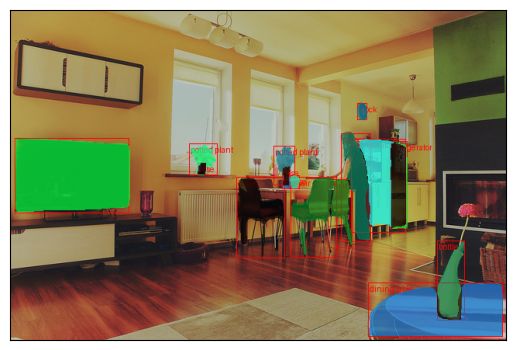

Mask label: bear, IoU = 0.9529572412524454, FP = 6852, FN = 6446


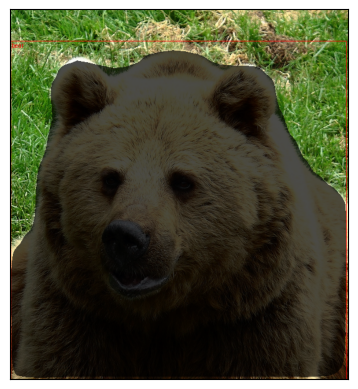

Mask label: potted plant, IoU = 0.8781746570691294, FP = 324, FN = 573
Mask label: chair, IoU = 0.8187038556193601, FP = 904, FN = 201
Mask label: potted plant, IoU = 0.7874564459930313, FP = 397, FN = 213
Mask label: bed, IoU = 0.9600463937978817, FP = 1462, FN = 1156
Mask label: book, IoU = 0.018356026222894603, FP = 0, FN = 19466
Mask label: book, IoU = 0.032246633593196315, FP = 2731, FN = 0
Mask label: book, IoU = 0.040310370931112796, FP = 5071, FN = 0


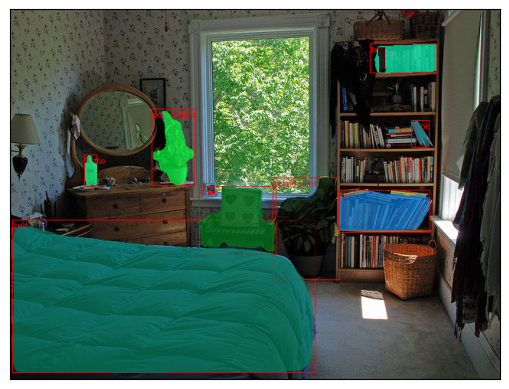

Mask label: stop sign, IoU = 0.9782961582396441, FP = 187, FN = 174
Mask label: stop sign, IoU = 0.7786069651741293, FP = 81, FN = 8
Mask label: truck, IoU = 0.36435643564356435, FP = 590, FN = 52


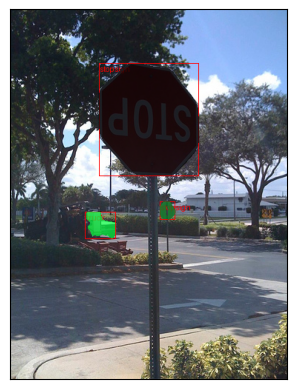

Mask label: teddy bear, IoU = 0.8212242275802534, FP = 14715, FN = 3095
Mask label: teddy bear, IoU = 0.6677151893324216, FP = 37343, FN = 1531
Mask label: teddy bear, IoU = 0.381398468035166, FP = 29504, FN = 29531
Mask label: teddy bear, IoU = 0.003189334623174824, FP = 39023, FN = 26924


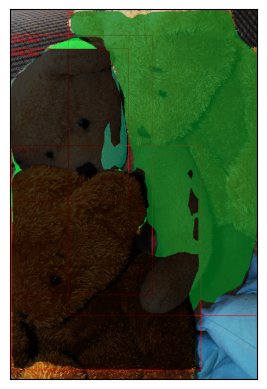

Mask label: person, IoU = 0.878075302433057, FP = 1668, FN = 1920
Mask label: skis, IoU = 0.37960467205750226, FP = 624, FN = 2138


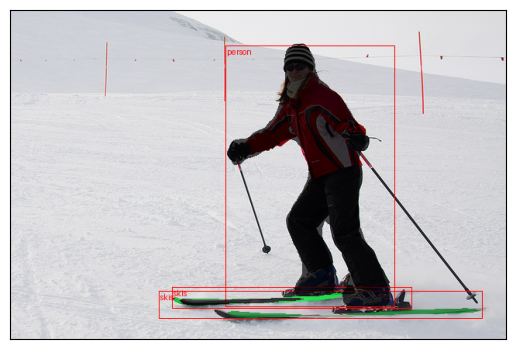

Mask label: oven, IoU = 0.9352877144251341, FP = 428, FN = 1296
Mask label: refrigerator, IoU = 0.9299386457988905, FP = 2102, FN = 1712


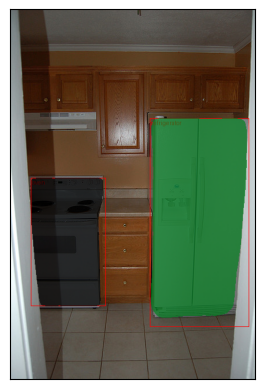

Mask label: person, IoU = 0.7653109502865053, FP = 8990, FN = 4403
Mask label: person, IoU = 0.5296906994288177, FP = 2093, FN = 10999
Mask label: sports ball, IoU = 0.6479289940828402, FP = 100, FN = 19
Mask label: sports ball, IoU = 0.5188133140376266, FP = 51, FN = 614


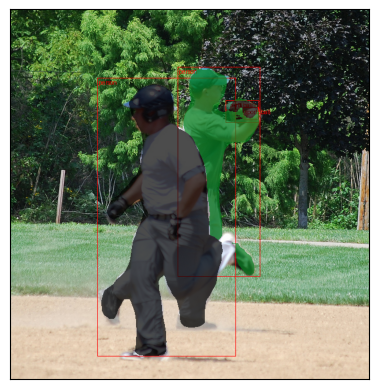

Mask label: person, IoU = 0.8859481107435139, FP = 1029, FN = 281
Mask label: person, IoU = 0.847165991902834, FP = 919, FN = 138
Mask label: tennis racket, IoU = 0.9305993690851735, FP = 106, FN = 26
Mask label: person, IoU = 0.8573116691285081, FP = 536, FN = 430
Mask label: person, IoU = 0.7147766323024055, FP = 18, FN = 148
Mask label: person, IoU = 0.6191646191646192, FP = 122, FN = 33
Mask label: person, IoU = 0.48289473684210527, FP = 367, FN = 26
Mask label: person, IoU = 0.22099447513812154, FP = 276, FN = 288
Mask label: person, IoU = 0.01405152224824356, FP = 414, FN = 428


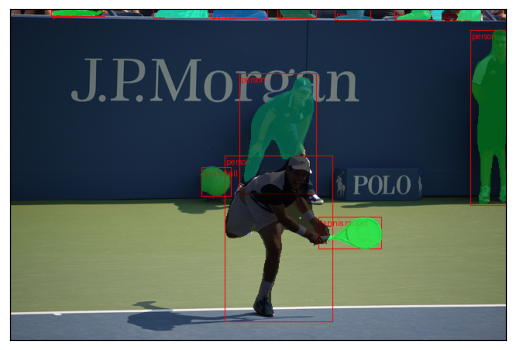

Mask label: person, IoU = 0.8423795476892822, FP = 1463, FN = 140
Mask label: person, IoU = 0.8167066955655791, FP = 2712, FN = 417
Mask label: person, IoU = 0.9075572387674299, FP = 739, FN = 1409
Mask label: person, IoU = 0.9025839358780338, FP = 714, FN = 1024
Mask label: person, IoU = 0.8150459921156373, FP = 3049, FN = 892
Mask label: person, IoU = 0.8297495917256397, FP = 1000, FN = 251
Mask label: person, IoU = 0.7899201185868402, FP = 620, FN = 1931
Mask label: person, IoU = 0.6688344172086043, FP = 1169, FN = 2803
Mask label: person, IoU = 0.8327072376659154, FP = 182, FN = 486
Mask label: person, IoU = 0.9043478260869565, FP = 87, FN = 23
Mask label: person, IoU = 0.2874885972914181, FP = 7440, FN = 2714
Mask label: tennis racket, IoU = 0.7947629157820241, FP = 349, FN = 231


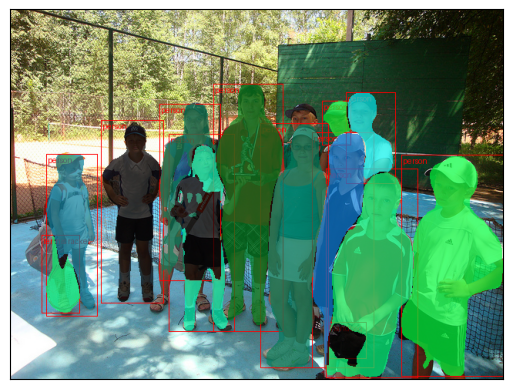

Mask label: handbag, IoU = 0.8551372048500319, FP = 953, FN = 636
Mask label: person, IoU = 0.9481993093241243, FP = 161, FN = 49
Mask label: bird, IoU = 0.7907188353048226, FP = 61, FN = 169
Mask label: person, IoU = 0.6080722691861429, FP = 12767, FN = 1420
Mask label: person, IoU = 0.7584569732937686, FP = 58, FN = 349
Mask label: person, IoU = 0.8901220865704772, FP = 256, FN = 41
Mask label: backpack, IoU = 0.2861519607843137, FP = 968, FN = 197
Mask label: boat, IoU = 0.529270248596632, FP = 39, FN = 548


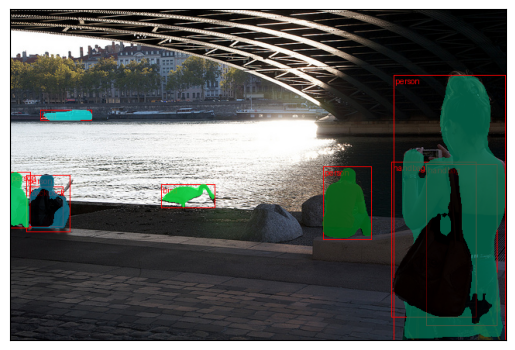

Mask label: person, IoU = 0.9256710184367325, FP = 2252, FN = 12306
Mask label: person, IoU = 0.8962129936996138, FP = 657, FN = 875
Mask label: cell phone, IoU = 0.9483895511032209, FP = 233, FN = 174
Mask label: person, IoU = 0.0030214126198712618, FP = 68304, FN = 0


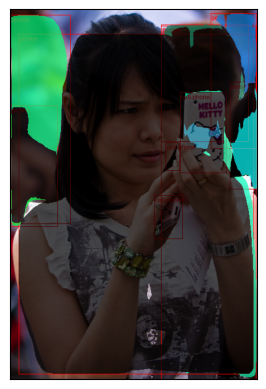

Mask label: person, IoU = 0.4599593036400633, FP = 11520, FN = 423
Mask label: person, IoU = 0.5995128740431455, FP = 542, FN = 609
Mask label: person, IoU = 0.28270843221009334, FP = 777, FN = 8291
Mask label: person, IoU = 0.6848512173128944, FP = 144, FN = 555


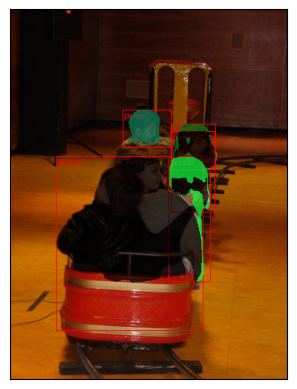

Mask label: bowl, IoU = 0.7472956126593477, FP = 99, FN = 6185
Mask label: dining table, IoU = 0.319066938176061, FP = 130517, FN = 231


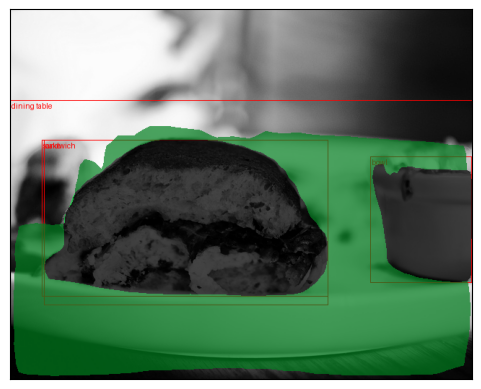

Mask label: person, IoU = 0.9041095890410958, FP = 119, FN = 126
Mask label: surfboard, IoU = 0.6526386105544422, FP = 472, FN = 48


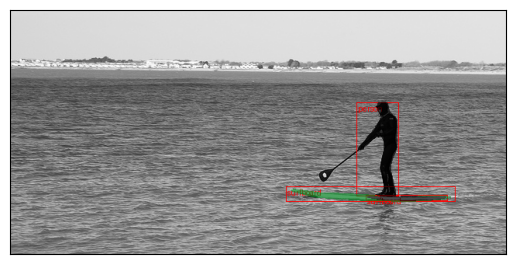

Mask label: mouse, IoU = 0.8672268907563025, FP = 42, FN = 37
Mask label: laptop, IoU = 0.9456809491126581, FP = 161, FN = 393
Mask label: keyboard, IoU = 0.9401648998822144, FP = 162, FN = 92
Mask label: tv, IoU = 0.9305387907385054, FP = 604, FN = 29


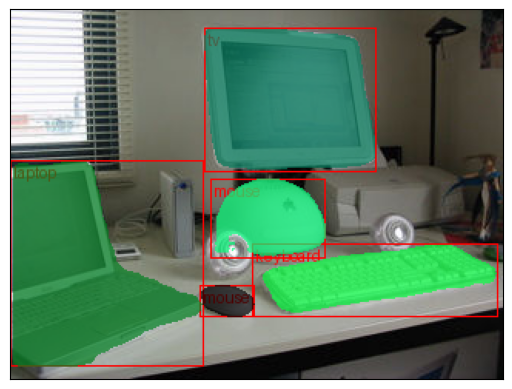

Mask label: car, IoU = 0.8205128205128205, FP = 63, FN = 56
Mask label: car, IoU = 0.9345504650361695, FP = 30, FN = 160
Mask label: car, IoU = 0.8812043093497499, FP = 890, FN = 345
Mask label: car, IoU = 0.012031466913465988, FP = 338, FN = 3932
Mask label: car, IoU = 0.8989023685730791, FP = 1330, FN = 770
Mask label: car, IoU = 0.8747553816046967, FP = 15, FN = 49
Mask label: truck, IoU = 0.8415213946117274, FP = 204, FN = 96
Mask label: car, IoU = 0.04873294346978557, FP = 265, FN = 223


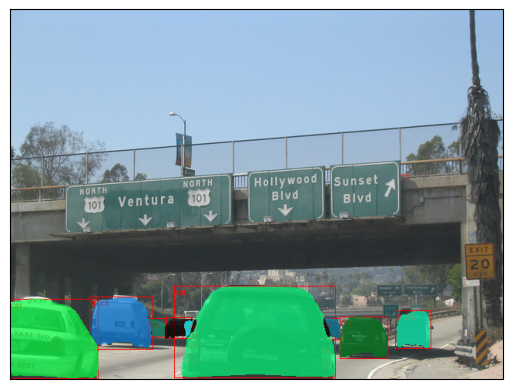

Mask label: bus, IoU = 0.9636134588210201, FP = 889, FN = 4570
Mask label: bus, IoU = 0.8806339772164438, FP = 320, FN = 162
Mask label: person, IoU = 0.7867647058823529, FP = 94, FN = 80
Mask label: person, IoU = 0.5711009174311926, FP = 146, FN = 41
Mask label: person, IoU = 0.7277743715511956, FP = 106, FN = 338
Mask label: bus, IoU = 0.9458157736303432, FP = 45, FN = 135
Mask label: person, IoU = 0.7197149643705463, FP = 100, FN = 18
Mask label: person, IoU = 0.7314662273476112, FP = 28, FN = 135


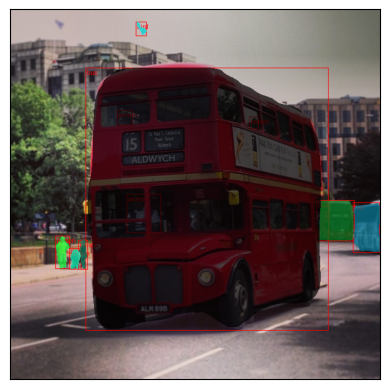

Mask label: cat, IoU = 0.9381795297520219, FP = 5435, FN = 3799


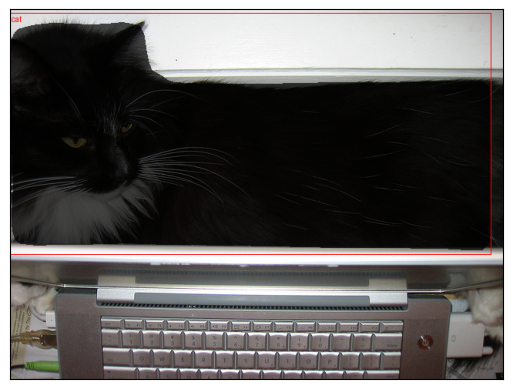

Mask label: airplane, IoU = 0.7233201581027668, FP = 190, FN = 20
Mask label: airplane, IoU = 0.8086206896551724, FP = 276, FN = 57


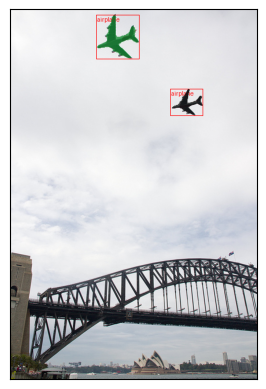

In [24]:
# инференс
imgs_num = 20
confidence_threshold = 0.7
mask_confidence = 0.5
iou_confidence = 0
for i in range(imgs_num):
  img, ann = val_dataset[i]
  
  with torch.no_grad():
    output = model([img.to(device)])[0]

  #pred masks, bbox, labels
  scores = output["scores"]
  masks = output["masks"][scores > confidence_threshold]
  masks = masks.squeeze(1) > mask_confidence
  bbox = output["boxes"][scores > confidence_threshold]
  labels = output["labels"][scores > confidence_threshold]
  labels_names = [categories[label.item()] for label in labels]

  gt_anns = val_dataset.coco.loadAnns(val_dataset.coco.getAnnIds(val_dataset[i][1][0]["image_id"]))
  gt_mask = [val_dataset.coco.annToMask(mask) for mask in gt_anns]
  gt_mask = [torch.from_numpy(mask == 1) for mask in gt_mask]
  gt_mask = torch.stack(gt_mask)
  gt_bbox = [torch.from_numpy(np.array(ann["bbox"])) for ann in gt_anns]
  gt_bbox = torchvision.ops.box_convert(torch.stack(gt_bbox), "xywh", "xyxy")
  gt_labels_names = [categories[elem["category_id"]] for elem in gt_anns]

  img_processed = draw_bounding_boxes(img, bbox, labels_names, "red")
  img_processed = draw_segmentation_masks(img_processed, masks, 0.7)
  #img_processed = draw_bounding_boxes(img_processed, gt_bbox, gt_labels_names, "green")
  #img_processed = draw_segmentation_masks(img_processed, gt_mask, 0.4, "green")

  idx = []
  for j in range(len(masks)):
    np_mask = masks[j].cpu().numpy()
    iou = 0
    fn = 0
    fp = 0
    temp_idx = -1
    for k in range(len(gt_mask)):
      np_gt_mask = gt_mask[k].cpu().numpy()
      temp_iou = get_iou(mask=np_mask, gt_mask=np_gt_mask)
      if temp_iou > iou:
        if k in idx:
          continue
        iou = temp_iou
        fn, fp, tp = calculate_metrics(gt_mask=np_gt_mask, mask=np_mask)
        temp_idx = k
    if temp_idx not in idx and temp_idx != -1 and iou > iou_confidence:
      idx.append(temp_idx)
      print(f"Mask label: {labels_names[j]}, IoU = {iou}, FP = {fp}, FN = {fn}")
    
  show(img_processed)



#### 2.6 Исследование параметров маски и confidence

Проведите серию экспериментов: протестируйте разные значения mask_threshold (0.3, 0.5, 0.7), протестируйте разные значения confidence_threshold, найдите оптимальное значение, при котором достигается лучший баланс между точностью и полнотой:


In [39]:
def show_plot(precision, recall, x_axis_values, title_value):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(f"Зависимость Precision и Recall от mask_threshold при conf_threshold = {title_value}")
    ax.plot(x_axis_values, precision, label="Precision")
    ax.plot(x_axis_values, recall, label="Recall")
    ax.legend()
    ax.set_xlabel("Mask threshold")
    ax.set_ylabel("Precision/Recall")
    ax.set_xticks(x_axis_values)
    plt.show()

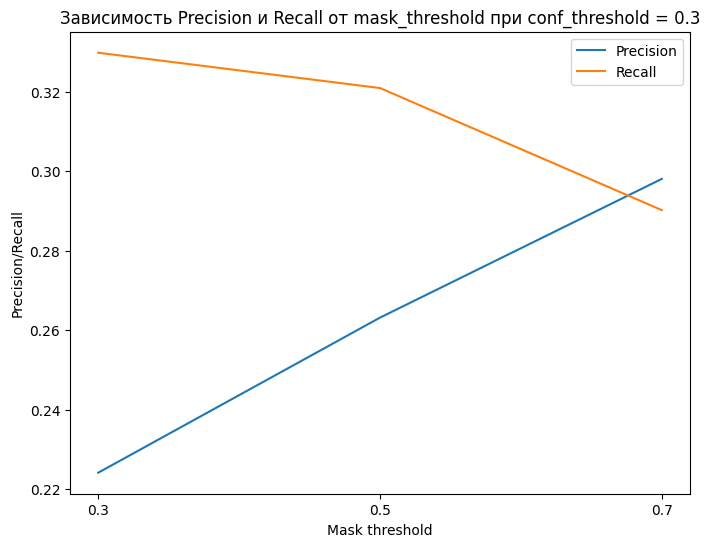

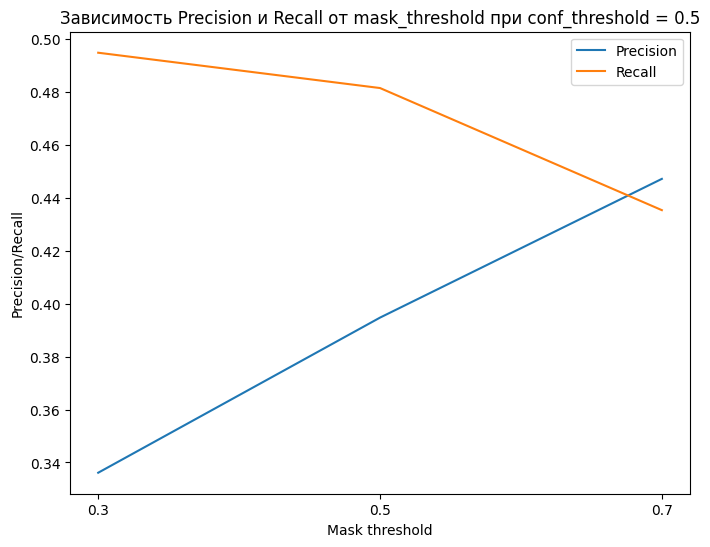

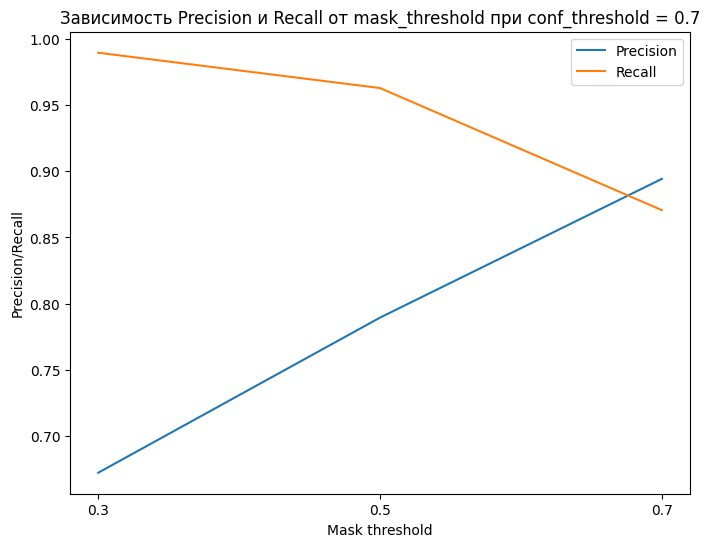

Лучшие показатели достигаются при conf_threshold = 0.7 и mask_threshold = 0.7


In [44]:
# исследование
conf_thresholds = [0.3, 0.5, 0.7]
mask_thresholds = [0.3, 0.5, 0.7]
best_value = -10000
best_conf_mask = [-1, -1]
for conf_t in conf_thresholds:
    p_r_values = {"precision":[], "recall":[]}
    for mask_t in mask_thresholds:
        # инференс
        imgs_num = 20
        mean_precision = 0
        mean_recall = 0
        for i in range(imgs_num):
            img, ann = val_dataset[i]
        
        with torch.no_grad():
            output = model([img.to(device)])[0]

        #pred masks, bbox, labels
        scores = output["scores"]
        masks = output["masks"][scores > conf_t]
        masks = masks.squeeze(1) > mask_t
        bbox = output["boxes"][scores > conf_t]
        labels = output["labels"][scores > conf_t]
        labels_names = [categories[label.item()] for label in labels]

        gt_anns = val_dataset.coco.loadAnns(val_dataset.coco.getAnnIds(val_dataset[i][1][0]["image_id"]))
        gt_mask = [val_dataset.coco.annToMask(mask) for mask in gt_anns]
        gt_mask = [torch.from_numpy(mask == 1) for mask in gt_mask]
        gt_mask = torch.stack(gt_mask)
        gt_bbox = [torch.from_numpy(np.array(ann["bbox"])) for ann in gt_anns]
        gt_bbox = torchvision.ops.box_convert(torch.stack(gt_bbox), "xywh", "xyxy")
        gt_labels_names = [categories[elem["category_id"]] for elem in gt_anns]

        img_processed = draw_bounding_boxes(img, bbox, labels_names, "red")
        img_processed = draw_segmentation_masks(img_processed, masks, 0.7, "red")
        #img_processed = draw_bounding_boxes(img_processed, gt_bbox, gt_labels_names, "green")
        img_processed = draw_segmentation_masks(img_processed, gt_mask, 0.4, "green")

        idx = []
        for j in range(len(masks)):
            np_mask = masks[j].cpu().numpy()
            iou = 0
            fn = 0
            fp = 0
            temp_idx = -1
            for k in range(len(gt_mask)):
                np_gt_mask = gt_mask[k].cpu().numpy()
                temp_iou = get_iou(mask=np_mask, gt_mask=np_gt_mask)
                if temp_iou > iou:
                    if k in idx:
                        continue
                    iou = temp_iou
                    fn, fp, tp = calculate_metrics(gt_mask=np_gt_mask, mask=np_mask)
                    temp_idx = k
                if temp_idx not in idx and temp_idx != -1 and iou > iou_confidence:
                    idx.append(temp_idx)
                    mean_precision += (tp / (tp + fp))
                    mean_recall += (tp / (tp + fn))
        mean_precision /= len(masks)
        mean_recall /= len(masks)
        temp_val = mean_precision + mean_recall
        if temp_val > best_value:
            best_value = temp_val
            best_conf_mask[0], best_conf_mask[1] = conf_t, mask_t
        p_r_values["precision"].append(mean_precision)
        p_r_values["recall"].append(mean_recall)
    show_plot(p_r_values["precision"], p_r_values["recall"], mask_thresholds, str(conf_t))
print(f"Лучшие показатели достигаются при conf_threshold = {best_conf_mask[0]} и mask_threshold = {best_conf_mask[1]}")


